In [241]:
import warnings
warnings.filterwarnings('ignore')

In [242]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [243]:
pd.set_option('display.max_columns', 100)

In [244]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [245]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,196,Republicans
1,286,Democrats
2,212,Republicans
3,194,Republicans
4,284,Democrats
...,...,...
19995,206,Republicans
19996,276,Democrats
19997,235,Democrats
19998,253,Democrats


In [246]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,147,1,0.005,Republicans
1,162,1,0.005,Republicans
2,169,1,0.005,Republicans
3,170,2,0.010,Republicans
4,172,1,0.005,Republicans


In [247]:
np.unique(seat_sims['seats']).shape[0]

186

In [248]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [249]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-08-30,229.365800,US House,seats
1,2026-08-30,66.120000,US House,chance
2,2026-08-30,22.784344,US House,seats_sd
3,2026-08-30,44.972806,AK-AL,y_pred
4,2026-08-30,3.555839,AK-AL,y_pred_sd


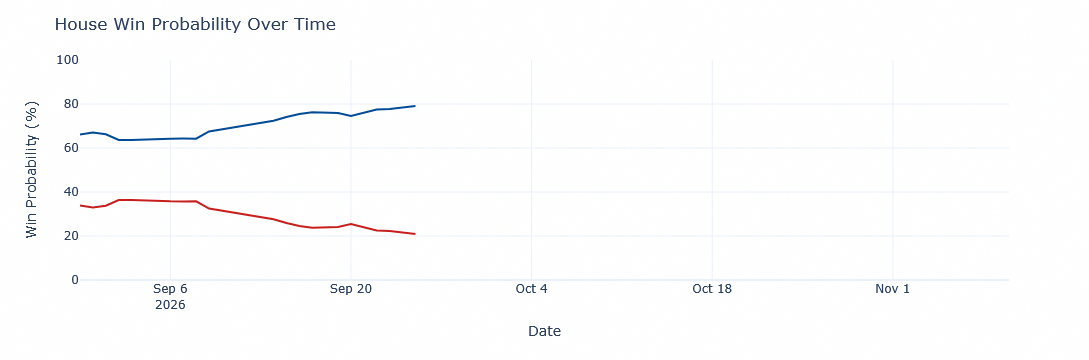

In [250]:
chance_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="House Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

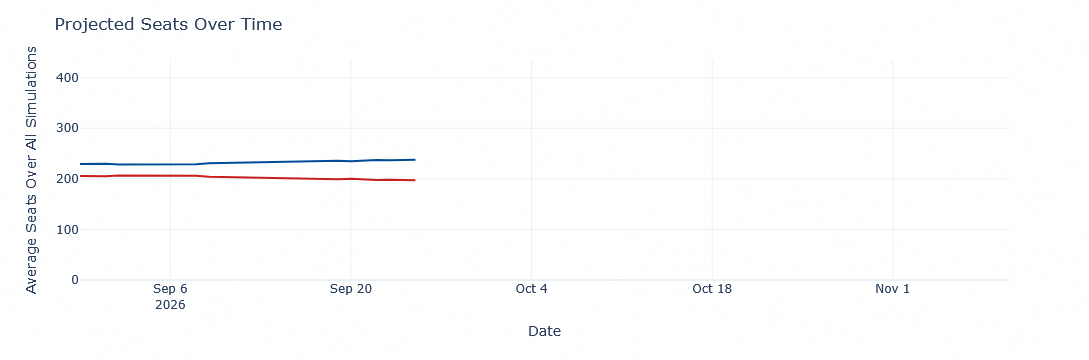

In [251]:
seats_over_time = output_ts[(output_ts['geo'] == 'US House') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 435 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-08-30'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 435]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [252]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [253]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [254]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,19950,19951,19952,19953,19954,19955,19956,19957,19958,19959,19960,19961,19962,19963,19964,19965,19966,19967,19968,19969,19970,19971,19972,19973,19974,19975,19976,19977,19978,19979,19980,19981,19982,19983,19984,19985,19986,19987,19988,19989,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-9.320101,0.160303,-6.794330,-13.236080,0.403460,-7.687046,1.577264,-8.879654,-1.309807,-1.423340,-7.259020,-4.020749,-5.220504,-7.544500,-2.495305,-2.755995,-5.292693,-1.254580,-1.932078,1.421975,-7.094901,-2.901960,-2.382163,0.912759,1.356583,-7.924052,-1.943977,-5.288665,-3.186006,-4.067987,-3.868279,-10.246510,-1.945999,-2.722996,-0.620678,-9.052242,-10.719475,-3.633067,-1.994813,-1.933447,-2.560899,-4.617614,-3.274973,-6.872652,-6.462767,1.341325,-3.864190,-2.733686,-5.770494,-8.863989,...,-6.845797,-3.105751,-2.437625,-6.535880,-4.536762,-5.684746,-2.493256,-6.688629,3.865195,-3.431682,-8.575636,-9.438743,-2.858342,-6.697571,-2.193937,-6.844371,1.193247,-7.255380,1.474350,-6.826451,-2.175648,-7.900006,-2.804558,-8.561167,-5.014774,-1.814874,-5.301730,-2.467109,-4.399770,-0.991894,-8.624631,0.341667,-10.458590,6.382725,-10.334546,-7.946773,-2.256945,-4.748223,-8.122515,-1.125441,-5.770262,-7.572296,-1.873403,-3.548523,-0.518989,-8.712529,-1.823037,-3.632840,-8.507739,-6.764017
AL-01,-20.411642,-5.231259,-19.063702,-19.981972,-8.375086,-17.027542,-6.777803,-20.105686,-7.642661,-11.000081,-16.995612,-14.831764,-12.080612,-8.477139,-12.713154,-13.569668,-11.915105,-11.956705,-14.818406,-13.161591,-17.639158,-9.683993,-12.492325,-9.146359,-6.328272,-18.127434,-8.310273,-18.242032,-15.800991,-12.084413,-18.181895,-20.581661,-13.653729,-14.327195,-12.343996,-13.608472,-18.462409,-12.824996,-14.848688,-4.418752,-13.074849,-13.049167,-11.282058,-15.634657,-18.920941,-8.329005,-19.102034,-10.263305,-13.316477,-15.693874,...,-15.430115,-11.669345,-10.916739,-12.350541,-13.237963,-14.059213,-7.811691,-18.854052,-6.909079,-15.477196,-14.770671,-16.225822,-8.490557,-16.897277,-9.623964,-20.594713,-5.863509,-16.287744,-10.410859,-16.587949,-9.041175,-13.537118,-10.076088,-13.873020,-14.555683,-12.584599,-13.682196,-7.560107,-13.767332,-10.012007,-17.313481,-9.419785,-22.645283,-4.229116,-17.087811,-18.838250,-13.577326,-14.563444,-17.684943,-12.478475,-13.343805,-19.845106,-11.954109,-13.456575,-12.410071,-17.327062,-8.502672,-14.726902,-7.845269,-17.224357
AL-02,-9.259610,6.503426,-6.633387,-4.863155,4.118204,-3.851556,-1.696671,-2.701601,2.968363,0.280637,-0.192306,-0.465357,-3.244695,-1.661219,-2.951820,-1.297141,0.588420,-2.576911,1.861510,-0.822253,-5.667495,-2.113538,-1.238589,0.834802,3.212634,-6.904207,3.122198,-2.229660,-2.383530,4.169286,0.093996,-4.505125,-4.536718,2.445823,-3.459959,0.223134,-7.061009,-1.706256,-3.771769,2.326804,-1.162511,-1.331188,3.843761,-3.574979,-1.787834,6.952755,-7.088473,0.096088,-1.763616,-0.636102,...,3.016676,0.492043,0.234322,0.501779,-0.687983,-1.390221,-1.072213,-4.254052,0.408487,-0.846112,-3.109881,-4.923474,0.735699,-8.195363,2.289755,-7.303561,3.489544,-3.215786,2.002784,-0.182710,-1.987429,3.405568,3.465487,-2.108199,-4.236961,0.266989,-2.987439,1.964552,2.358752,2.528462,-8.324520,-3.015182,-7.193062,4.756266,-1.476017,4.238896,-0.907106,-4.062293,-2.916245,2.270708,-2.906639,-6.690732,-2.658648,0.044618,3.840553,-3.946961,4.110544,-2.727241,2.847689,-4.347055
AL-03,-24.201976,-16.649073,-25.287111,-26.903001,-17.153467,-23.193038,-14.822560,-18.278920,-17.094995,-18.651293,-17.696903,-21.029570,-19.912202,-14.764663,-19.671194,-18.155591,-21.366188,-21.657629,-21.495369,-15.752924,-25.066957,-18.256240,-18.370368,-12.537182,-12.583453,-26.587777,-14.715584,-24.447496,-23.773074,-19.299221,-21.760711,-24.221874,-15.829103,-21.331332,-15.521483,-17.378333,-24.990881,-17.279457,-22.185670,-17.980164,-22.238067,-20.590428,-17.888843,-22.297424,-22

In [255]:
sim_corr = post_untransp.corr()

In [256]:
sim_corr

,AK-AL,AL-01,AL-02,AL-03,AL-04,AL-05,AL-06,AL-07,AR-01,AR-02,AR-03,AR-04,AZ-01,AZ-02,AZ-03,AZ-04,AZ-05,AZ-06,AZ-07,AZ-08,AZ-09,CA-01,CA-02,CA-03,CA-05,CA-06,CA-08,CA-09,CA-10,CA-13,CA-15,CA-16,CA-17,CA-18,CA-19,CA-20,CA-21,CA-22,CA-23,CA-24,CA-25,CA-26,CA-27,CA-28,CA-30,CA-31,CA-32,CA-33,CA-35,CA-36,...,TX-25,TX-26,TX-27,TX-28,TX-29,TX-30,TX-31,TX-32,TX-33,TX-34,TX-35,TX-36,TX-37,TX-38,UT-01,UT-02,UT-03,UT-04,VA-01,VA-02,VA-03,VA-04,VA-05,VA-06,VA-07,VA-08,VA-09,VA-10,VA-11,VT-AL,WA-01,WA-02,WA-03,WA-04,WA-05,WA-06,WA-07,WA-08,WA-09,WA-10,WI-01,WI-03,WI-04,WI-05,WI-06,WI-07,WI-08,WV-01,WV-02,WY-AL
AK-AL,1.000000,0.713962,0.479339,0.734651,0.725255,0.715585,0.733312,0.492446,0.735136,0.737748,0.734221,0.737908,0.479980,0.483954,0.483803,0.497777,0.697839,0.718915,0.719804,0.720101,0.736590,0.697915,0.500832,0.506847,0.740224,0.730516,0.566027,0.505698,0.510129,0.503781,0.480494,0.694388,0.558347,0.501808,0.495579,0.700577,0.505191,0.738252,0.732104,0.505556,0.514679,0.703980,0.481608,0.507628,0.479343,0.517642,0.548503,0.506120,0.564336,0.507504,...,0.735294,0.718259,0.542034,0.505306,0.502071,0.702164,0.741167,0.699355,0.529827,0.502092,0.701497,0.520307,0.490729,0.493936,0.487960,0.729860,0.719220,0.719984,0.739029,0.547956,0.501839,0.474005,0.717521,0.731370,0.484038,0.505786,0.734216,0.484172,0.697685,0.527410,0.504344,0.507658,0.481652,0.700895,0.534749,0.480080,0.498980,0.505750,0.565400,0.490676,0.738439,0.536353,0.568960,0.732596,0.738373,0.697348,0.722642,0.731129,0.714252,0.696520
AL-01,0.713962,1.000000,0.486085,0.740712,0.732818,0.725228,0.739606,0.499496,0.738845,0.742752,0.740926,0.743216,0.486365,0.487673,0.495529,0.503107,0.701550,0.722845,0.723406,0.721195,0.738864,0.699692,0.505628,0.510206,0.746181,0.728834,0.569657,0.517914,0.512383,0.507774,0.493185,0.697356,0.566115,0.506388,0.506999,0.705392,0.512135,0.739117,0.732569,0.508889,0.516159,0.700378,0.485433,0.510212,0.483664,0.531804,0.560679,0.513523,0.575475,0.510402,...,0.736920,0.721345,0.556219,0.512887,0.502796,0.698923,0.746342,0.703747,0.541287,0.509479,0.704175,0.525859,0.496050,0.504992,0.493031,0.735320,0.724684,0.723919,0.742133,0.553169,0.513420,0.487651,0.711847,0.732464,0.483344,0.509368,0.741183,0.487152,0.705503,0.533969,0.505240,0.511618,0.485623,0.706826,0.541303,0.487900,0.504278,0.509922,0.573804,0.496587,0.739982,0.545137,0.575409,0.737150,0.746320,0.703822,0.722776,0.742696,0.720670,0.705135
AL-02,0.479339,0.486085,1.000000,0.489628,0.485412,0.477348,0.490989,0.699837,0.487483,0.495733,0.487733,0.496194,0.670610,0.665890,0.674354,0.690801,0.638124,0.475334,0.482063,0.475464,0.492426,0.630489,0.699315,0.706246,0.498233,0.488445,0.579329,0.697795,0.699042,0.520373,0.665850,0.633243,0.569063,0.695105,0.701722,0.635736,0.699684,0.493118,0.484430,0.705547,0.708499,0.634769,0.674943,0.700990,0.668890,0.536031,0.556169,0.703984,0.577320,0.706609,...,0.493827,0.480258,0.552455,0.699974,0.697263,0.631363,0.493642,0.635230,0.543961,0.696717,0.634986,0.534625,0.682529,0.680591,0.674203,0.485163,0.471241,0.478427,0.492987,0.551991,0.690970,0.666000,0.472232,0.486299,0.667118,0.708437,0.490602,0.668777,0.632348,0.540737,0.701105,0.698603,0.678536,0.639542,0.543609,0.662944,0.694640,0.694829,0.578022,0.683361,0.487887,0.544617,0.576508,0.488242,0.493432,0.635938,0.478926,0.493290,0.479511,0.639910
AL-03,0.734651,0.740712,0.489628,1.000000,0.754910,0.739736,0.765069,0.509815,0.753535,0.761326,0.759019,0.759597,0.497660,0.498103,0.500185,0.513975,0.717020,0.737318,0.736022,0.740271,0.760603,0.720287,0.515254,0.517647,0.761980,0.750965,0.577490,0.518049,0.525899,0.523221,0.498713,0.714544,0.571296,0.512160,0.512813,0.724874,0.520744,0.757823,0.751708,0.516549,0.526724,0.719218,0.498145,0.518979,0.495029,0.540721,0.570806,0.519253,0.581996,0.524391,...,0.757149,0.740228,0.558593,0.518171,0.514852,0.715489,0.766412,0.720091,0.543652,0.516081,0.721246,0.535863,0.502828,0.512641,0.502658,0.752581,0.740161,0.738597,0.760217,0.561046,0.514156,0.493038,0.73615

In [257]:
post.shape

(418, 20000)

In [258]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [259]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:29<00:00, 680.79it/s]


array(['PA-08', 'SC-01', 'OH-07', ..., 'MI-10', 'MI-10', 'MI-10'],
      shape=(20000,), dtype='<U32')

In [260]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.290492,-18.764506,-1,-37.529012,45.976780,3.551857,12.855,1,38.988921,52.938557
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.620113,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.254169,-38.923019,0,-77.846039,36.913887,3.556745,0.005,2,30.017374,43.927567
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.620113,1,0,46.957206,0.529278,46.963324,0.529278,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.529278,0.727515,0.006119,-4.423302,-19.716169,1,-39.432338,48.707832,3.446764,35.260,3,41.910828,55.450431
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,5,18.397008,0.000000,0.000000,0.000000,-37.022070,-45.710827,-1,-91.421653,30.320968,3.459770,0.000,4,23.592143,37.191458
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,3,8.220432,0.000000,0.000000,0.000000,-57.314166,-47.132870,-1,-94.265741,20.495563,3.504452,0.000,5,13.668229,27.397851


In [261]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.290492,-18.764506,-1,-37.529012,45.976780,3.551857,12.855,1,38.988921,52.938557,0.095
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.620113,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.254169,-38.923019,0,-77.846039,36.913887,3.556745,0.005,2,30.017374,43.927567,0.000
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.620113,1,0,46.957206,0.529278,46.963324,0.529278,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.529278,0.727515,0.006119,-4.423302,-19.716169,1,-39.432338,48.707832,3.446764,35.260,3,41.910828,55.450431,1.105
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,5,18.397008,0.000000,0.000000,0.000000,-37.022070,-45.710827,-1,-91.421653,30.320968,3.459770,0.000,4,23.592143,37.191458,0.000
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,3,8.220432,0.000000,0.000000,0.000000,-57.314166,-47.132870,-1,-94.265741,20.495563,3.504452,0.000,5,13.668229,27.397851,0.000


In [262]:
data.sort_values('tipping_point_prob', ascending=False).head(10)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
98,98,FL-22,Pia Dandiya,Casey Askar,False,False,FL,22,"DANDIYA, PIA","ASKAR, CASEY",1965051.29,57760.00,2022811.29,97.144568,2.855432,Florida,FL-22,53.931205,26.984941,3.703933,0.199203,13.186062,27.190634,-0.817400,-4.551960,-3.618320,91.180168,44.697986,0.987401,-8.620113,0,0,46.286766,0.561416,44.430149,0.561416,South Atlantic,2026,0.0,0.00000,0.00000,12,1222,6,9437.067100,0.561416,0.749277,-1.856617e+00,1.383473,47.144568,0,94.289136,52.221421,3.602368,73.355,99,45.075439,59.375026,3.065
229,229,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,2799701.44,0.00,2799701.44,100.000000,0.000000,North Carolina,NC-11,88.740422,3.902084,0.797632,1.120840,3.305854,24.807640,-7.843347,-4.057125,-5.003681,49.294326,45.192821,0.987401,-8.620113,0,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.0,0.00000,0.00000,37,3711,3,10000.000000,0.000000,0.000000,0.000000e+00,-1.387248,50.000000,0,100.000000,51.374902,3.613695,64.915,230,44.303423,58.534353,2.955
183,183,ME-02,Matt Dunlap,Paul LePage,False,False,ME,2,"DUNLAP, MATT","LEPAGE, PAUL",1181075.25,1415549.45,2596624.70,45.485019,54.514981,Maine,ME-02,94.623805,1.542589,0.598455,0.552005,0.848532,26.920000,-5.410176,-3.867301,-4.253020,26.830060,45.382645,0.987401,-8.620113,0,0,50.368753,1.579567,46.241137,1.579567,New England,2026,0.0,0.25284,-0.25284,23,2302,3,2068.886995,1.579567,1.256808,-4.127616e+00,0.114073,-4.514981,0,-9.029961,51.345902,3.599582,64.775,184,44.249330,58.506288,2.935
193,193,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",1135198.13,1290223.21,2425421.34,46.804162,53.195838,Michigan,MI-10,76.551128,2.316124,5.150984,0.123322,13.269372,29.340000,-2.765891,-2.592362,-2.635744,99.999226,46.657584,0.987401,-8.620113,0,0,45.000000,0.205781,45.000000,0.205781,East North Central,2026,0.0,0.00000,0.00000,26,2610,2,2190.629568,0.205781,0.453631,-1.460326e-07,3.348625,-3.195838,0,-6.391676,51.103739,3.595549,62.135,194,44.011254,58.194391,2.905
273,273,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",3706160.25,3186004.97,6892165.22,53.773526,46.226474,New York,NY-17,70.961924,14.978446,4.840493,0.059866,7.686273,48.490000,2.820018,1.029915,1.477441,87.206472,50.279862,0.987401,-8.620113,0,1,45.156078,0.143722,49.869935,0.143722,Mid-Atlantic,2026,0.0,0.00000,0.00000,36,3617,0,2891.592088,0.143722,0.379107,4.713858e+00,11.574996,3.773526,-1,7.547052,51.737318,3.493194,69.005,274,44.954928,58.642698,2.715
314,314,PA-07,Bob Brooks,Ryan Mackenzie,False,True,PA,7,"BROOKS, BOB","MACKENZIE, RYAN EDWARD",1942165.53,1493241.01,3435406.54,56.533790,43.466210,Pennsylvania,PA-07,75.458946,15.481046,2.435986,0.030199,4.952274,31.050000,-1.956264,-0.869379,-1.141100,81.633883,48.380567,0.987401,-8.620113,0,1,45.002910,0.947609,40.004365,0.947609,Mid-Atlantic,2026,0.0,0.00000,0.00000,42,4207,2,3196.069448,0.947609,0.973452,-4.998545e+00,6.337913,6.533790,-1,13.067581,51.767379,3.510744,69.505,315,44.820820,58.664899,2.710
123,123,IA-03,Sarah Trone Garriott,Zach Nunn,False,True,IA,3,"TRONE GARRIOTT, SARAH","NUNN, ZACH",4755754.76,1010301.85,5766056.61,82.478461,17.521539,Iowa,IA-03,86.341081,5.022950,2.732262,0.063009,3.929259,35.410000,-2.445778,-1.482072,-1.722998,77.628515,47.767874,0.987401,-8.

In [263]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Bill Hill']
    indie_r = ['Kevin Kiley']
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [264]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.290492,-18.764506,-1,-37.529012,45.976780,3.551857,12.855,1,38.988921,52.938557,0.095,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs..."
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.620113,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.254169,-38.923019,0,-77.846039,36.913887,3.556745,0.005,2,30.017374,43.927567,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<..."
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.620113,1,0,46.957206,0.529278,46.963324,0.529278,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.529278,0.727515,0.006119,-4.423302,-19.716169,1,-39.432338,48.707832,3.446764,35.260,3,41.910828,55.450431,1.105,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)..."
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,5,18.397008,0.000000,0.000000,0.000000,-37.022070,-45.710827,-1,-91.421653,30.320968,3.459770,0.000,4,23.592143,37.191458,0.000,Safe R,"<b style=""color:#366bbf;"">Lee McInnis (D)</b> ..."
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,3,8.220432,0.000000,0.000000,0.000000,-57.314166,-47.132870,-1,-94.265741,20.495563,3.504452,0.000,5,13.668229,27.397851,0.000,Safe R,"<b style=""color:#366bbf;"">Amanda Pusczek (D)</..."


In [265]:
data['projected_winner'] = data['chance'].map(lambda x: '(D)' if x > 50 else '(R)')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.290492,-18.764506,-1,-37.529012,45.976780,3.551857,12.855,1,38.988921,52.938557,0.095,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R)
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.620113,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.254169,-38.923019,0,-77.846039,36.913887,3.556745,0.005,2,30.017374,43.927567,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R)
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.620113,1,0,46.957206,0.529278,46.963324,0.529278,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.529278,0.727515,0.006119,-4.423302,-19.716169,1,-39.432338,48.707832,3.446764,35.260,3,41.910828,55.450431,1.105,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R)


In [266]:
pvi_24 = pd.read_csv('../../transformed/pvi/past_pres_results_by24dist.csv')
data = pd.merge(left=data, right=pvi_24[['district', 'party']], left_on='cd', right_on='district')
data = data.rename({'party': 'curr_party'}, axis=1)
data['hold'] = data['projected_winner'] ==  data['curr_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.620113,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.0,0.0,0.0,-4.290492,-18.764506,-1,-37.529012,45.976780,3.551857,12.855,1,38.988921,52.938557,0.095,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.620113,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.0,0.0,0.0,-26.254169,-38.923019,0,-77.846039,36.913887,3.556745,0.005,2,30.017374,43.927567,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,


In [267]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.290492,-18.764506,-1,-37.529012,45.976780,3.551857,12.855,1,38.988921,52.938557,0.095,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+8.0
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.620113,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.254169,-38.923019,0,-77.846039,36.913887,3.556745,0.005,2,30.017374,43.927567,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+26.2
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.620113,1,0,46.957206,0.529278,46.963324,0.529278,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.529278,0.727515,0.006119,-4.423302,-19.716169,1,-39.432338,48.707832,3.446764,35.260,3,41.910828,55.450431,1.105,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+2.6


In [268]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.290492,-18.764506,-1,-37.529012,45.976780,3.551857,12.855,1,38.988921,52.938557,0.095,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+8.0,87.145,12.9,87.1,12.9%,87.1%
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.620113,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.254169,-38.923019,0,-77.846039,36.913887,3.556745,0.005,2,30.017374,43.927567,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+26.2,99.995,0.0,100.0,<1%,>99%
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.620113,1,0,46.957206,0.529278,46.963324,0.529278,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.529278,0.727515,0.006119,-4.423302,-19.716169,1,-39.432338,48.707832,3.446764,35.260,3,41.910828,55.450431,1.105,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+2.6,64.740,35.3,64.7,35.3%,64.7%


In [269]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.620113,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.000000,0.000000,0.000000,-4.290492,-18.764506,-1,-37.529012,45.976780,3.551857,12.855,1,38.988921,52.938557,0.095,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+8.0,87.145,12.9,87.1,12.9%,87.1%,5.646686
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.620113,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.000000,0.000000,0.000000,-26.254169,-38.923019,0,-77.846039,36.913887,3.556745,0.005,2,30.017374,43.927567,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+26.2,99.995,0.0,100.0,<1%,>99%,10.172246
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-8.620113,1,0,46.957206,0.529278,46.963324,0.529278,East South Central,2026,0.0,0.0,0.0,1,102,5,917.110424,0.529278,0.727515,0.006119,-4.423302,-19.716169,1,-39.432338,48.707832,3.446764,35.260,3,41.910828,55.450431,1.105,Tilt R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+2.6,64.740,35.3,64.7,35.3%,64.7%,11.880092


In [270]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-8.620113,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,5,975.656077,0.0,0.0,0.0,-4.290492,-18.764506,-1,-37.529012,45.976780,3.551857,12.855,1,38.988921,52.938557,0.095,Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+8.0,87.145,12.9,87.1,12.9%,87.1%,5.646686,D+5.6
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-8.620113,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,5,122.699498,0.0,0.0,0.0,-26.254169,-38.923019,0,-77.846039,36.913887,3.556745,0.005,2,30.017374,43.927567,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+26.2,99.995,0.0,100.0,<1%,>99%,10.172246,D+10.2


In [271]:
data['geoid']

0       200
1       101
2       102
3       103
4       104
       ... 
413    5507
414    5508
415    5401
416    5402
417    5600
Name: geoid, Length: 418, dtype: int64

In [272]:
dem_uclen = dem_uncont.shape[0]
dem_uncont['rating'] = np.full(dem_uclen, 'Safe D')
dem_uncont['chance'] = np.full(dem_uclen, 100)
dem_uncont['y_pred'] = np.full(dem_uclen, 100)
dem_uncont['swing_24_to_26'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_24_to_26_swing'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_dem_chance'] = np.full(dem_uclen, '100%')
dem_uncont['disp_rep_chance'] = np.full(dem_uclen, '0%')
dem_uncont['projected_2p_margin'] = np.full(dem_uclen, 'D+100')
dem_uncont['flip_indic'] = np.full(dem_uclen, '')
dem_uncont = dem_uncont.drop(['Unnamed: 0'], axis=1)
dem_uncont['matchup'] = dem_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                      x['dem_inc_any'], x['rep_inc_any']), axis=1)
dem_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-04,Mike Thompson/Eric Jones,Not Contested,True,False,CA,4,6,604,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Mike Thompson/Eric J..."
1,CA-07,Doris Matsui/Mai Vang,Not Contested,True,False,CA,7,6,607,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Doris Matsui/Mai Van..."
2,CA-11,Scott Weiner/Connie Chan,Not Contested,False,False,CA,11,6,611,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Scott Weiner/Connie ..."
3,CA-12,Lateefah Simon,Not Contested,True,False,CA,12,6,612,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Lateefah Simon* (D)<..."
4,CA-14,Aisha Wahab/Melissa Hernandez,Not Contested,True,False,CA,14,6,614,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Aisha Wahab/Melissa ..."


In [273]:
rep_uclen = rep_uncont.shape[0]
rep_uncont['rating'] = np.full(rep_uclen, 'Safe R')
rep_uncont['chance'] = np.full(rep_uclen, 0)
rep_uncont['y_pred'] = np.full(rep_uclen, 0)
rep_uncont['swing_24_to_26'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_24_to_26_swing'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_dem_chance'] = np.full(rep_uclen, '0%')
rep_uncont['disp_rep_chance'] = np.full(rep_uclen, '100%')
rep_uncont['projected_2p_margin'] = np.full(rep_uclen, 'R+100')
rep_uncont['flip_indic'] = np.full(rep_uclen, '')
rep_uncont = rep_uncont.drop(['Unnamed: 0'], axis=1)
rep_uncont['matchup'] = rep_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                       x['dem_inc_any'], x['rep_inc_any']), axis=1)
rep_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-40,Not Contested,Young Kim/Ken Calvert,False,True,CA,40,6,640,Safe R,0,0,NaN,NaN,0%,100%,R+100,,"<b style=""color:#366bbf;"">Not Contested (D)</b..."


In [274]:
incl_cols = ['cd', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'geoid', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = pd.concat([data[incl_cols], dem_uncont[incl_cols], rep_uncont[incl_cols]], axis=0)
disp_data.shape

(435, 16)

In [275]:
tab_data = data[['cd', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Bill Hill', 'Kevin Kiley'] else x)
tab_data = tab_data.rename({
    'cd': 'District',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,District,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,AK-AL,Bill Hill (Ind),Nick Begich,Likely R,"<p style=""color:blue;"">12.9%</p>","<p style=""color:red;"">87.1%</p>",R+8.0,D+5.6,0.095
1,AL-01,Clyde Jones Jr.,Jerry Carl,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+26.2,D+10.2,0.000
2,AL-02,Shomari Figures,Rhett Marques,Tilt R,"<p style=""color:blue;"">35.3%</p>","<p style=""color:red;"">64.7%</p>",R+2.6,D+11.9,1.105
3,AL-03,Lee McInnis,Mike Rogers,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+39.4,D+7.7,0.000
4,AL-04,Amanda Pusczek,Robert Aderholt,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+59.0,D+8.0,0.000


In [276]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

4.177270965919556

In [277]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,237.897600
1,chamber_win_chance,79.045000
0,sv_bias,4.177271


In [278]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [279]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 435 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,79.045,237.8976
1,Republicans,20.955,197.1024


In [280]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')